In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv('student_performance_dataset-selected-columns.csv')
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8


In [3]:
df.shape

(1000, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   str    
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    str    
 6   internet_access             1000 non-null   str    
 7   extracurricular_activities  1000 non-null   str    
 8   part_time_job               1000 non-null   str    
 9   previous_grade              1000 non-null   float64
dtypes: float64(4), int64(1), str(5)
memory usage: 98.8 KB


In [5]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900
std,288.819436,1.478559,9.270685,1.203527,12.613425
min,1.000000,0.500000,54.800000,3.200000,31.300000
25%,250.750000,2.600000,78.800000,5.900000,61.000000
50%,500.500000,3.600000,85.200000,6.800000,69.600000
75%,750.250000,4.500000,91.900000,7.600000,78.400000
max,1000.000000,8.100000,100.000000,10.000000,100.000000


In [6]:
df.isnull().sum()

student_id                      0
gender                          0
study_time_hours                0
attendance_percent              0
sleep_hours                     0
parental_education            102
internet_access                 0
extracurricular_activities      0
part_time_job                   0
previous_grade                  0
dtype: int64

In [7]:
df_clean = df.drop(columns=['student_id'])

df_clean['parental_education'] = df_clean['parental_education'].fillna('Unknown')

In [8]:
df_clean['parental_education'].value_counts()

parental_education
High School    356
Bachelors      308
Masters        184
Unknown        102
PhD             50
Name: count, dtype: int64

In [9]:
df_clean.duplicated().sum()

np.int64(0)

In [10]:
df_clean['previous_grade'].max()

np.float64(100.0)

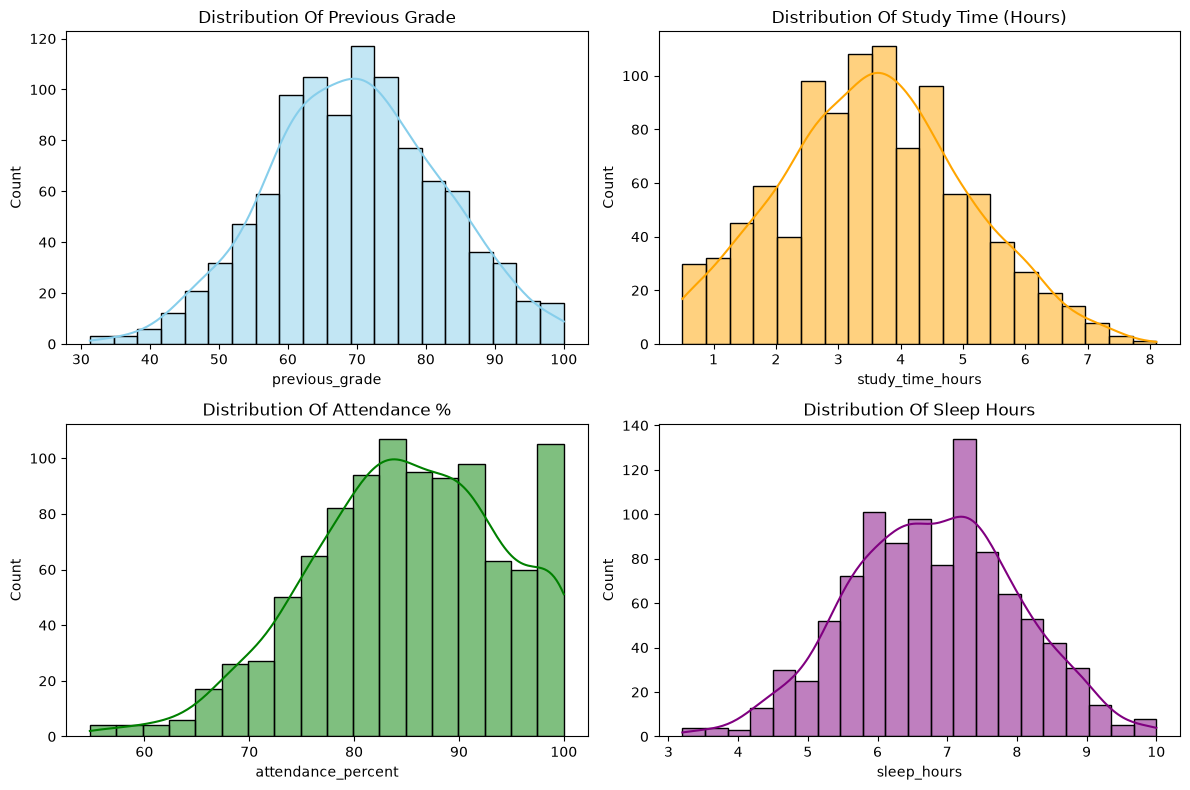

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df_clean['previous_grade'], kde=True, ax=axes[0,0], color='skyblue')
axes[0, 0].set_title('Distribution Of Previous Grade')

sns.histplot(df_clean['study_time_hours'], kde=True, ax=axes[0,1], color='orange')
axes[0, 1].set_title('Distribution Of Study Time (Hours)')

sns.histplot(df_clean['attendance_percent'], kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('Distribution Of Attendance %')

sns.histplot(df_clean['sleep_hours'], kde=True, ax=axes[1,1], color='purple')
axes[1,1].set_title('Distribution Of Sleep Hours')

plt.tight_layout()
plt.show()

/var/folders/4q/rmb_b9l12v51q3_6z0q6qwj40000gn/T/ipykernel_56284/1767774048.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='parental_education', palette='Set2')


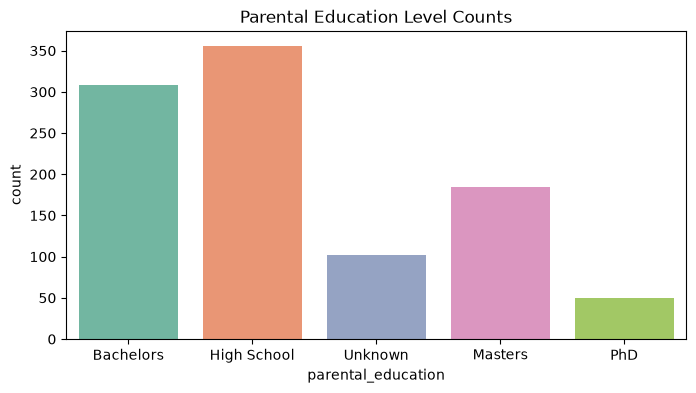

In [12]:
# Count plot for parental education
plt.figure(figsize=(8, 4))
sns.countplot(data=df_clean, x='parental_education', palette='Set2')
plt.title('Parental Education Level Counts')
plt.show()


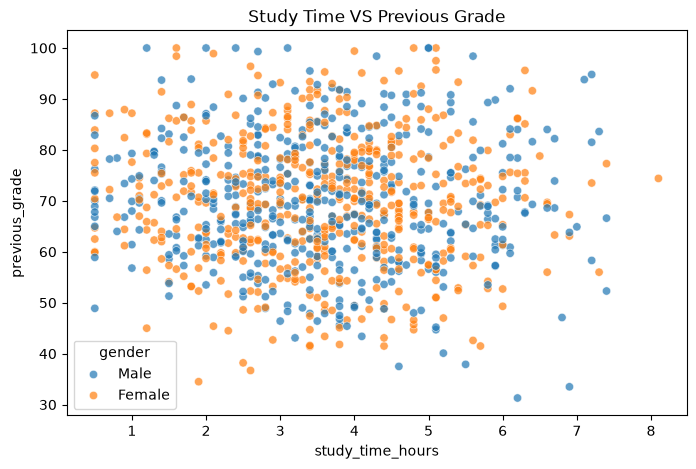

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_clean, x = 'study_time_hours', y='previous_grade', hue='gender', alpha=0.7)
plt.title('Study Time VS Previous Grade')
plt.show()

/var/folders/4q/rmb_b9l12v51q3_6z0q6qwj40000gn/T/ipykernel_56284/191860550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


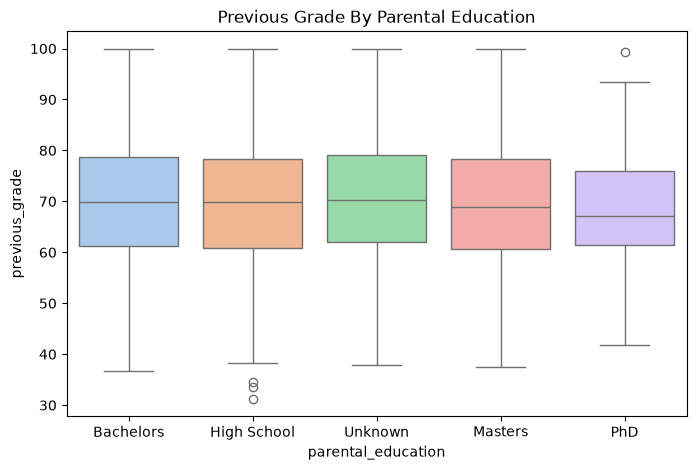

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x = 'parental_education',
    y = 'previous_grade',
    palette = 'pastel'
)
plt.title('Previous Grade By Parental Education')
plt.show()